In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys, os
from glob import glob
import imageio.v2 as imageio

In [2]:
# NOTE ON THE DATASET
# The course uses Food-5K (food vs non-food), but that download is now dead:
#   - https://lazyprogrammer.me/course_files/Food-5K.zip  -> 404
#   - EPFL FTP (ftp://tremplin.epfl.ch, FoodImage folder) -> backend host
#     grebvm2.epfl.ch is unreachable / times out
# So we use the ants-vs-bees dataset from PyTorch's own official transfer
# learning tutorial instead. It is the same kind of problem (small, 2-class
# image classification), already in ImageFolder layout, and only ~45MB.
# If you ever get Food-5K (e.g. from Kaggle: trolukovich/food5k-image-dataset),
# you only need to change the two ImageFolder paths further down.

!wget -nc https://download.pytorch.org/tutorial/hymenoptera_data.zip

File ‘hymenoptera_data.zip’ already there; not retrieving.



In [3]:
!unzip -qq -o hymenoptera_data.zip

In [4]:
!ls

1.PyTorch-Linear-Regression.ipynb
10.PyTorch-Simple-RNN-Sine.ipynb
10.PyTorch-Simple-RNN-Sine1-with-noise.ipynb
11.PyTorch-Understanding-RNN-Shapes.ipynb
12.PyTorch-Nonlinear-Sequence-Simple-RNN.ipynb
12.PyTorch-Nonlinear-Sequence-linear.ipynb
13.PyTorch-Nonlinear-Sequence-LSTM.ipynb
14.PyTorch-RNN-Image-Classifier.ipynb
15.PyTorch-Stock-Returns.ipynb
16.PyTorch-Text-Processing.ipynb
17.Custom-PyTorch-Text-Classification-using-RNN.ipynb
18.Custom-PyTorch-Text-Classification-using-CNN.ipynb
19.PyTorch-Recommender-20M-Unmodified.ipynb
19.PyTorch-Recommender-20M1-Modified.ipynb
2.PyTorch-Regression-Moore's-Law.ipynb
20.PyTorch-Recommender-20M-with-Predictions.ipynb
21.PyTorch-Transfer-Learning-with-Data-Augmentation.ipynb
3.PyTorch-Linear-Classification-with-Logits.ipynb
3.PyTorch-Linear-Classification.ipynb
4.PyTorch-ANN-MNIST.ipynb
5.PyTorch-Regression.ipynb
6.PyTorch-CNN-Fashion-MNIST.ipynb
7.PyTorch-CIFAR.ipynb
8.PyTorch-CIFAR-Improved.ipynb
9.PyTorch-Autoregressive-Model.ipynb
9.PyTo

Your job is to classify whether an image is an ant or a bee.

The data is already laid out the way `datasets.ImageFolder` expects — one
subfolder per class — so unlike the course video we don't need any `mkdir`/`mv`
shuffling to reorganize it:

```
hymenoptera_data/
    train/
        ants/   (124 images)
        bees/   (121 images)
    val/
        ants/   (70 images)
        bees/   (83 images)
```

In [5]:
!ls hymenoptera_data/train
!ls hymenoptera_data/train/ants | head -5

ants bees
0013035.jpg
1030023514_aad5c608f9.jpg
1095476100_3906d8afde.jpg
1099452230_d1949d3250.jpg
116570827_e9c126745d.jpg


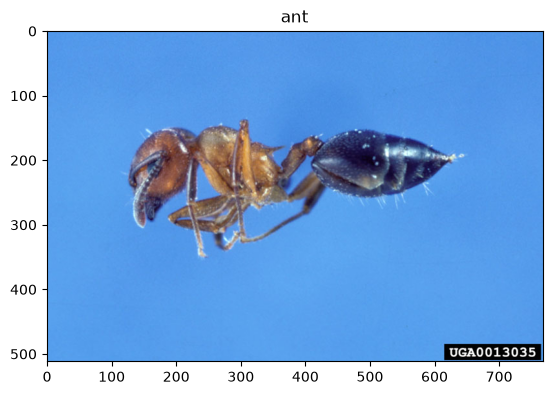

In [6]:
# look at an image for fun
plt.imshow(imageio.imread('hymenoptera_data/train/ants/0013035.jpg'))
plt.title('ant')
plt.show()

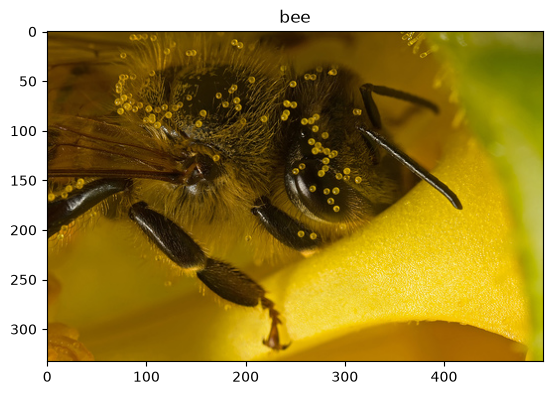

In [7]:
# ImageFolder assigns labels alphabetically: ants -> 0, bees -> 1
plt.imshow(imageio.imread('hymenoptera_data/train/bees/1092977343_cb42b38d62.jpg'))
plt.title('bee')
plt.show()

In [8]:
# Note: normalize mean and std are standardized for ImageNet
# https://github.com/pytorch/examples/blob/97304e232807082c2e7b54c597615dc0ad8f6173/imagenet/main.py#L197-L198
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(),
        transforms.CenterCrop(size=224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

We pass in the paths to the image files and the transforms that we just created.

In [9]:
train_dataset = datasets.ImageFolder(
    'hymenoptera_data/train',
    transform=train_transform
)
test_dataset = datasets.ImageFolder(
    'hymenoptera_data/val',
    transform=test_transform
)

print(train_dataset.classes, '->', train_dataset.class_to_idx)
print('train size:', len(train_dataset), ' test size:', len(test_dataset))

['ants', 'bees'] -> {'ants': 0, 'bees': 1}
train size: 244  test size: 153


In [10]:
# Note: the course uses batch_size=128, but that was for Food-5K's 3000 train
# images. This dataset only has 245, so 128 would give just 2 gradient updates
# per epoch. 32 gives 8 updates/epoch, which actually converges.
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
)

In [11]:
# Define the model
try:
  model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
except AttributeError:
  # older torchvision versions
  model = models.vgg16(pretrained=True)

# Freeze VGG weights
for param in model.parameters():
  param.requires_grad = False

In [12]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [13]:
# We want to replace the `classifier`
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [14]:
n_features = model.classifier[0].in_features
n_features

25088

In [15]:
# We're doing binary classification
model.classifier = nn.Linear(n_features, 2)

In [16]:
# Let's see what the model is now
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [17]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)
model.to(device)

mps


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

we can see that the classifier attribute now refers to our own linear layer

In [18]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

actually after this everything is the same as before.

In [19]:
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  for it in range(epochs):
    t0 = datetime.now()
    train_loss = []
    for inputs, targets in train_loader:
      # move data to GPU
      inputs, targets = inputs.to(device), targets.to(device)

      # zero the parameter gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(inputs)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

    # Get train loss and test loss
    train_loss = np.mean(train_loss) # a little misleading

    test_loss = []
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      test_loss.append(loss.item())
    test_loss = np.mean(test_loss)

    # Save losses
    train_losses[it] = train_loss
    test_losses[it] = test_loss

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, \
      Test Loss: {test_loss:.4f}, Duration: {dt}')

  return train_losses, test_losses

In [20]:
train_losses, test_losses = batch_gd(
    model,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    epochs=5,
)

Epoch 1/5, Train Loss: 0.6293,       Test Loss: 0.4510, Duration: 0:00:04.924858
Epoch 2/5, Train Loss: 0.1435,       Test Loss: 0.6082, Duration: 0:00:04.827472
Epoch 3/5, Train Loss: 0.0664,       Test Loss: 0.6242, Duration: 0:00:04.860700
Epoch 4/5, Train Loss: 0.0473,       Test Loss: 0.6080, Duration: 0:00:04.945342
Epoch 5/5, Train Loss: 0.0532,       Test Loss: 0.6272, Duration: 0:00:04.676989


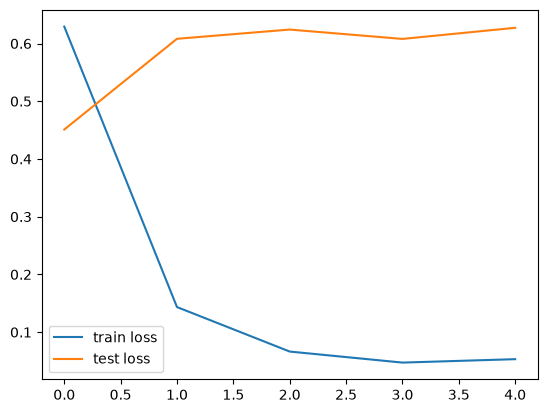

In [21]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

at the last for iteration and we calculate the accuracy

In [22]:
# Accuracy

n_correct = 0.
n_total = 0.
for inputs, targets in train_loader:
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  # torch.max returns both max and argmax
  _, predictions = torch.max(outputs, 1)

  # update counts
  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

train_acc = n_correct / n_total


n_correct = 0.
n_total = 0.
for inputs, targets in test_loader:
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  # torch.max returns both max and argmax
  _, predictions = torch.max(outputs, 1)

  # update counts
  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

test_acc = n_correct / n_total
print(f"Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")

Train acc: 0.9959, Test acc: 0.9216


And these are the results — high accuracy on a tiny image dataset (only 245
training images) using transfer learning. That's the whole point: the frozen
VGG16 feature extractor was already trained on ImageNet, so we only had to
learn a single new `Linear` layer on top of it.

The course video reports ~99% on Food-5K here; on ants-vs-bees you should
expect roughly 90-95%, since it's a harder, much smaller dataset.